# Node classification sweep performance 

Plots showing the performance for the graph classification on the CosMx Pancrease data with no diabetes and Type 1 Diabetes conditions.

- InterScale (GCN + Transformer)
- GCN
- PCATransformer

In [5]:
import os

# LRZ home
if os.path.exists("/dss/dsshome1/05/di93tig"):
    print('LRZ cluster')
    CLUSTER = 'LRZ'
    BASE_DIR_REPO = "/dss/dsshome1/05/di93tig/1_projects" 
    BASE_DIR_PROJECT = "/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale"
elif os.path.exists("/home/icb/francesca.drummer/"):
    print('HPC cluster')
    CLUSTER = 'HPC'
    BASE_DIR_REPO = "/home/icb/francesca.drummer/1-Projects/"
    BASE_DIR_PROJECT = ""
else:
    print('unkown')
    CLUSTER = 'unknown'
DATA = "melton25"

LRZ cluster


In [6]:
import sys
from pathlib import Path

# Add project root to path (go up 2 levels from notebook location)
project_root = Path(f'{BASE_DIR_REPO}/InterScale_reproducibility')
print(project_root)
sys.path.insert(0, str(project_root))

/dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility


In [7]:
import wandb
wandb.login()

True

In [30]:
import pandas as pd
# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
from src.wandb import Wandb_evaluation, plot_f1_across_seeds, plot_class_f1_comparison, set_plot_configs

ImportError: cannot import name 'plot_class_f1_robustness' from 'src.wandb' (/dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility/src/wandb.py)

In [9]:
import yaml
import matplotlib.pyplot as plt
import os

with open(os.path.join(BASE_DIR_REPO, "InterScale_reproducibility/figures/config.yml"), "r") as f:
    config = yaml.safe_load(f)

PALETTE = config["palettes"]["continuous"]
CELL_TYPE_COLORS = config["palettes"][DATA]

## Load WandB IDs

In [10]:
GNN_sweep = "l0jetvrz"
InterScale_sweep = "yqvyut7l"
PCATrans_sweep = "8govw06t"

## Graph Classification performance

In [11]:
SWEEP_GOAL = 'robustness'
CLASSES = ['Alpha', 'Acinar', 'Beta', 'Ductal', 'Endocrine', 'Immune', 'Mast', 'Beta', 'Endothelial']

Q: Why does PCATrans not have test_f1 scores?

In [12]:
GNN_wandb = Wandb_evaluation("GCN", GNN_sweep, SWEEP_GOAL, CLASSES)
PCATrans_wandb = Wandb_evaluation("PCATransformer", PCATrans_sweep, SWEEP_GOAL, CLASSES)
InterScale_wandb = Wandb_evaluation("InterScale", InterScale_sweep, SWEEP_GOAL, CLASSES)

In [13]:
GNN_wandb.get_dataframe().head()

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,test_f1_micro/avg,test_f1_class_Alpha,test_f1_class_Acinar,test_f1_class_Beta,test_f1_class_Ductal,test_f1_class_Endocrine,test_f1_class_Immune,test_f1_class_Mast,test_f1_class_Endothelial
0,nc6wcxh4,melton25_clas_node_44_GCN_,44,finished,0.5,150,None,583.736024,255145,0.410172,None,0.074074,0.577701,0.187302,0.483192,0.000000,0.219942,0.0,0.120466
1,n72wxcou,melton25_clas_node_44_GCN_,43,finished,0.5,150,None,610.241567,255145,0.345615,None,0.074074,0.741093,0.150794,0.000000,0.222222,0.160729,0.0,0.000000
2,qrvo7c6z,melton25_clas_node_44_GCN_,42,finished,0.5,150,None,623.258038,255145,0.229102,None,0.211111,0.552431,0.111111,0.012950,0.111111,0.143627,0.0,0.020202
3,ltgzyu44,melton25_clas_node_44_GCN_,41,finished,0.5,150,None,587.714794,255145,0.158501,None,0.111111,0.392892,0.055556,0.008230,0.055556,0.165252,0.0,0.055931
4,o6zttv7w,melton25_clas_node_44_GCN_,40,finished,0.5,150,None,594.628172,255145,0.357124,None,0.111111,0.492742,0.211111,0.474357,0.111111,0.191293,0.0,0.029440


In [ ]:
PCATrans_wandb.get_mean_and_std()

In [ ]:
GNN_wandb.plot_robustness(metric="test_acc", save_path = f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/node_class")

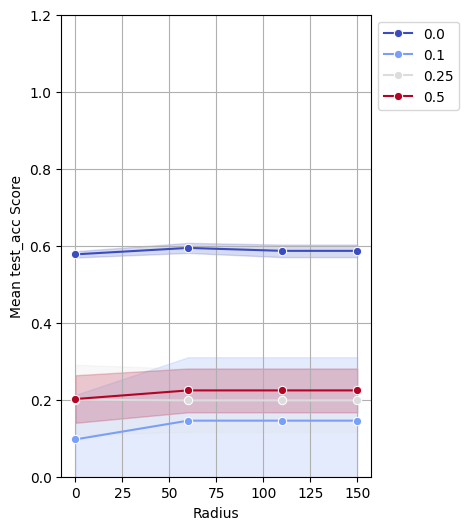

In [15]:
PCATrans_wandb.plot_robustness(metric="test_acc", save_path =  f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/node_class")

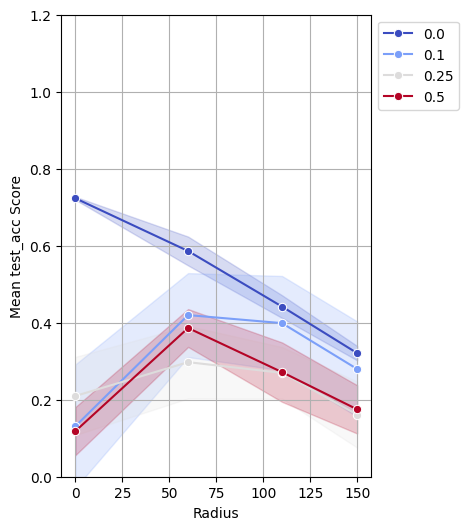

In [16]:
InterScale_wandb.plot_robustness(metric="test_acc", save_path =  f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/node_class")

## F1 score performance

In [17]:
wandb_evals = [GNN_wandb, PCATrans_wandb, InterScale_wandb]  # Your list of dataframes, PCATrans_wandb, InterScale_wandb

             model                      class      mean       std  n_seeds
0              GCN       test_f1_class_Acinar  0.528654  0.084491        5
1              GCN        test_f1_class_Alpha  0.107407  0.103439        5
2              GCN         test_f1_class_Beta  0.166667  0.055556        5
3              GCN       test_f1_class_Ductal  0.532613  0.085451        5
4              GCN    test_f1_class_Endocrine  0.044444  0.060858        5
5              GCN  test_f1_class_Endothelial  0.034815  0.056389        5
6              GCN       test_f1_class_Immune  0.146862  0.142870        5
7              GCN         test_f1_class_Mast  0.000000  0.000000        5
8       InterScale       test_f1_class_Acinar  0.413481  0.133942        5
9       InterScale        test_f1_class_Alpha  0.092593  0.085867        5
10      InterScale         test_f1_class_Beta  0.148889  0.064278        5
11      InterScale       test_f1_class_Ductal  0.327959  0.122502        5
12      InterScale    tes

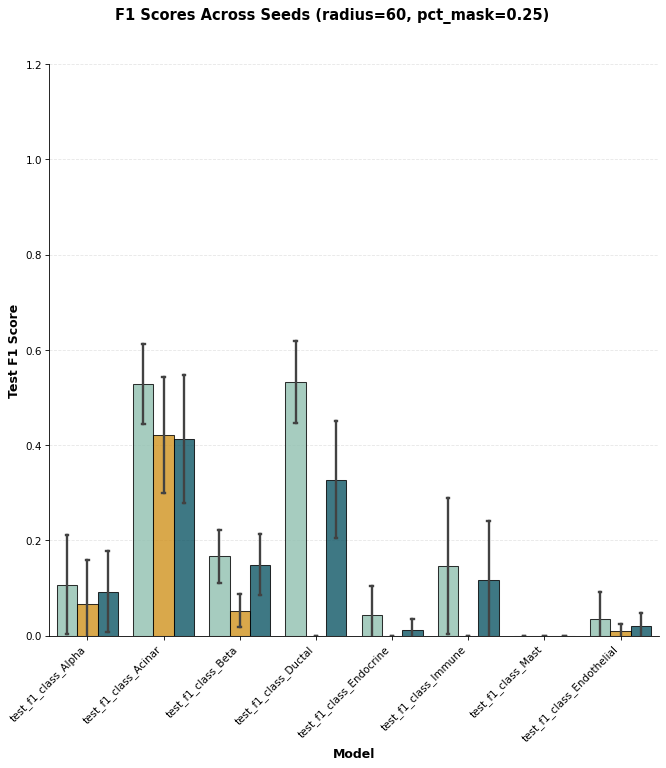

In [35]:

g, stats, plot_data = plot_f1_across_seeds(
    wandb_evaluations=wandb_evals,
    radius=60,
    pct_mask_nodes=0.25,
    BASE_DIR_REPO=BASE_DIR_REPO, 
    height=10,
    aspect=0.9,
    save_path=f'{DATA}/node_class/f1_comparison_models_radius'
)
plt.show()
#
# # Save with high DPI from config
# # g.savefig('f1_scores.png', bbox_inches='tight')
#
# # Print statistics:
# print(stats)

## Class robustness

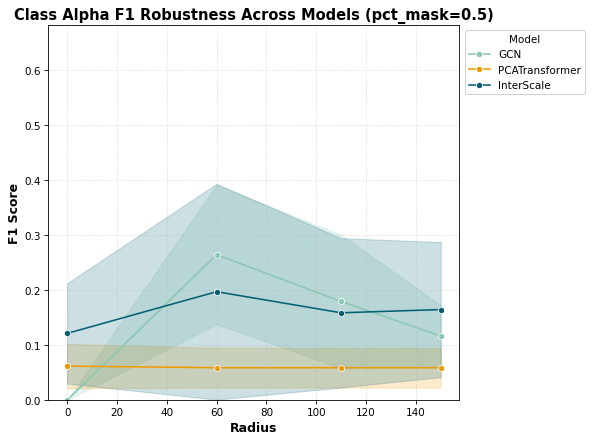


Statistics Summary:
         model  radius     mean      std  n_seeds
           GCN       0 0.000000 0.000000        5
           GCN      60 0.264444 0.126540        5
           GCN     110 0.179259 0.121310        5
           GCN     150 0.116296 0.056145        5
    InterScale       0 0.121164 0.091225        5
    InterScale      60 0.197037 0.196233        5
    InterScale     110 0.158624 0.135795        5
    InterScale     150 0.164550 0.122730        5
PCATransformer       0 0.061672 0.040315        5
PCATransformer      60 0.058813 0.036182        5
PCATransformer     110 0.058813 0.036182        5
PCATransformer     150 0.058813 0.036182        5


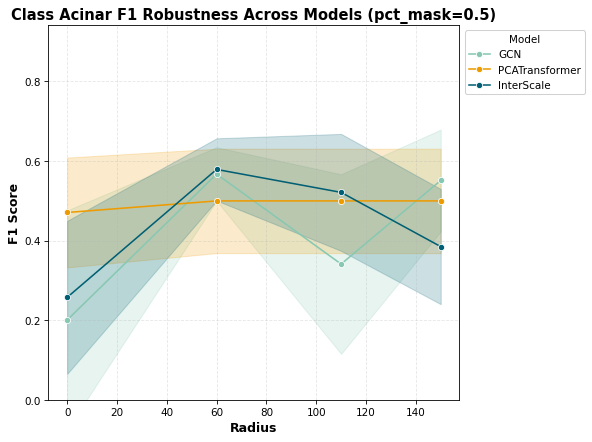


Statistics Summary:
         model  radius     mean      std  n_seeds
           GCN       0 0.200914 0.275124        5
           GCN      60 0.567361 0.067284        5
           GCN     110 0.341419 0.225413        5
           GCN     150 0.551372 0.127712        5
    InterScale       0 0.257761 0.192163        5
    InterScale      60 0.579076 0.078200        5
    InterScale     110 0.521441 0.146868        5
    InterScale     150 0.385295 0.144598        5
PCATransformer       0 0.470943 0.137971        5
PCATransformer      60 0.500001 0.131060        5
PCATransformer     110 0.500001 0.131060        5
PCATransformer     150 0.500001 0.131060        5


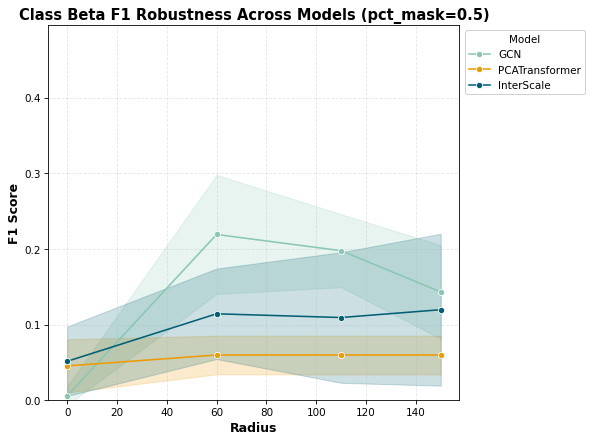


Statistics Summary:
         model  radius     mean      std  n_seeds
           GCN       0 0.005553 0.012417        5
           GCN      60 0.219259 0.078846        5
           GCN     110 0.197778 0.048333        5
           GCN     150 0.143175 0.061899        5
    InterScale       0 0.051287 0.046004        5
    InterScale      60 0.114198 0.059927        5
    InterScale     110 0.109259 0.086464        5
    InterScale     150 0.119630 0.100595        5
PCATransformer       0 0.045204 0.035288        5
PCATransformer      60 0.059649 0.025614        5
PCATransformer     110 0.059649 0.025614        5
PCATransformer     150 0.059649 0.025614        5


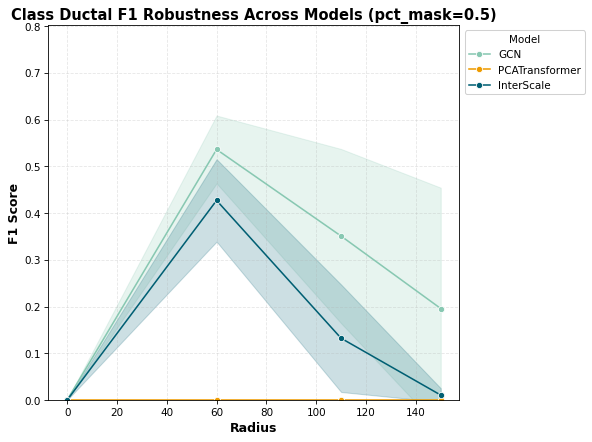


Statistics Summary:
         model  radius     mean      std  n_seeds
           GCN       0 0.000000 0.000000        5
           GCN      60 0.535978 0.072482        5
           GCN     110 0.350687 0.186290        5
           GCN     150 0.195746 0.258429        5
    InterScale       0 0.000000 0.000000        5
    InterScale      60 0.426934 0.088126        5
    InterScale     110 0.132157 0.114917        5
    InterScale     150 0.010598 0.014690        5
PCATransformer       0 0.000000 0.000000        5
PCATransformer      60 0.000000 0.000000        5
PCATransformer     110 0.000000 0.000000        5
PCATransformer     150 0.000000 0.000000        5


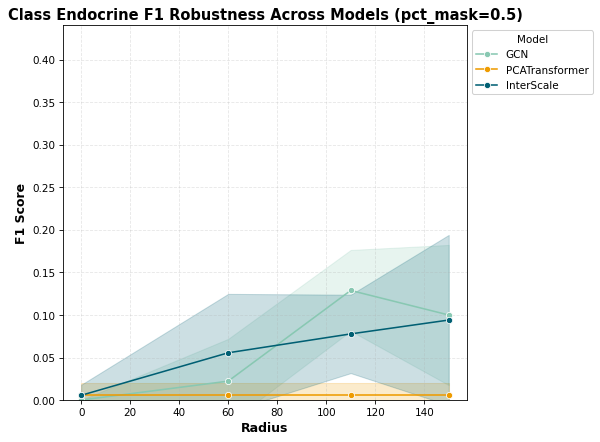


Statistics Summary:
         model  radius     mean      std  n_seeds
           GCN       0 0.000000 0.000000        5
           GCN      60 0.022222 0.049690        5
           GCN     110 0.128889 0.047604        5
           GCN     150 0.100000 0.082402        5
    InterScale       0 0.005556 0.012423        5
    InterScale      60 0.055556 0.069290        5
    InterScale     110 0.077778 0.046111        5
    InterScale     150 0.094074 0.100123        5
PCATransformer       0 0.006349 0.014197        5
PCATransformer      60 0.006349 0.014197        5
PCATransformer     110 0.006349 0.014197        5
PCATransformer     150 0.006349 0.014197        5


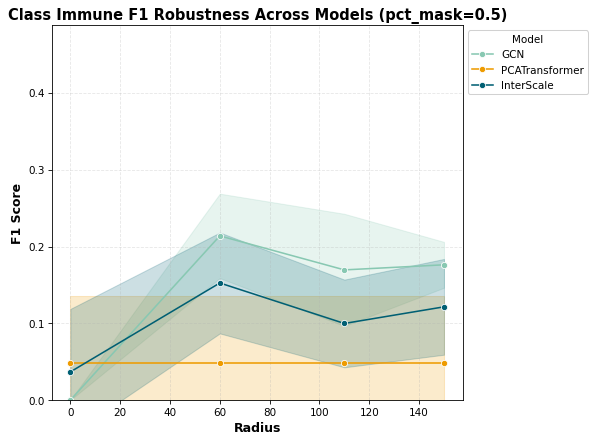


Statistics Summary:
         model  radius     mean      std  n_seeds
           GCN       0 0.000000 0.000000        5
           GCN      60 0.213871 0.054955        5
           GCN     110 0.169538 0.073041        5
           GCN     150 0.176169 0.029838        5
    InterScale       0 0.036682 0.082024        5
    InterScale      60 0.152497 0.065696        5
    InterScale     110 0.099759 0.057108        5
    InterScale     150 0.121413 0.062369        5
PCATransformer       0 0.048508 0.087645        5
PCATransformer      60 0.048508 0.087645        5
PCATransformer     110 0.048508 0.087645        5
PCATransformer     150 0.048508 0.087645        5


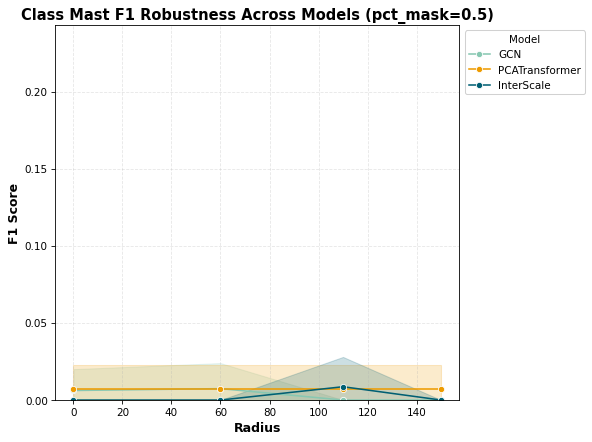


Statistics Summary:
         model  radius     mean      std  n_seeds
           GCN       0 0.006196 0.013855        5
           GCN      60 0.007407 0.016563        5
           GCN     110 0.000000 0.000000        5
           GCN     150 0.000000 0.000000        5
    InterScale       0 0.000000 0.000000        5
    InterScale      60 0.000000 0.000000        5
    InterScale     110 0.008642 0.019324        5
    InterScale     150 0.000000 0.000000        5
PCATransformer       0 0.006959 0.015561        5
PCATransformer      60 0.006959 0.015561        5
PCATransformer     110 0.006959 0.015561        5
PCATransformer     150 0.006959 0.015561        5


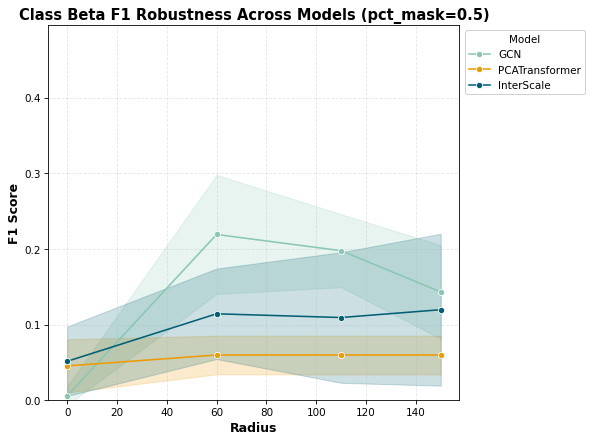


Statistics Summary:
         model  radius     mean      std  n_seeds
           GCN       0 0.005553 0.012417        5
           GCN      60 0.219259 0.078846        5
           GCN     110 0.197778 0.048333        5
           GCN     150 0.143175 0.061899        5
    InterScale       0 0.051287 0.046004        5
    InterScale      60 0.114198 0.059927        5
    InterScale     110 0.109259 0.086464        5
    InterScale     150 0.119630 0.100595        5
PCATransformer       0 0.045204 0.035288        5
PCATransformer      60 0.059649 0.025614        5
PCATransformer     110 0.059649 0.025614        5
PCATransformer     150 0.059649 0.025614        5


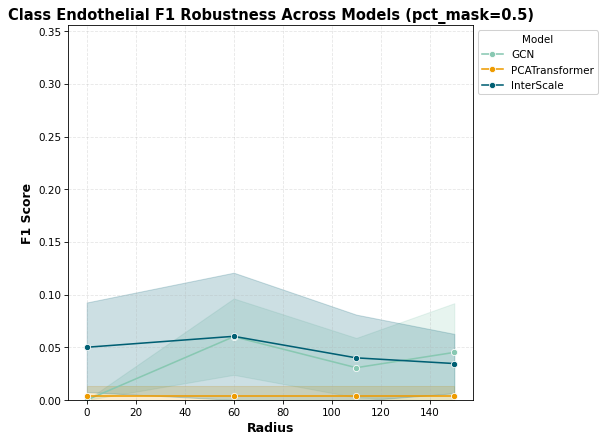


Statistics Summary:
         model  radius     mean      std  n_seeds
           GCN       0 0.000000 0.000000        5
           GCN      60 0.060121 0.036189        5
           GCN     110 0.030688 0.028176        5
           GCN     150 0.045208 0.046627        5
    InterScale       0 0.050079 0.042458        5
    InterScale      60 0.060460 0.060350        5
    InterScale     110 0.040019 0.041003        5
    InterScale     150 0.034625 0.028124        5
PCATransformer       0 0.004040 0.009035        5
PCATransformer      60 0.004040 0.009035        5
PCATransformer     110 0.004040 0.009035        5
PCATransformer     150 0.004040 0.009035        5


In [39]:
for class_id in CLASSES: 
    fig, ax, stats = plot_class_f1_robustness(
        wandb_evals,
        class_idx=class_id,
        pct_mask_nodes=0.5,
        BASE_DIR_REPO=BASE_DIR_REPO, 
        save_path=f"{BASE_DIR_REPO}/InterScale_reproducibility/figures/{DATA}/node_class"
    )